In [42]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
def run_umap(adata,nfeatures=2000,batch_key = None,min_dist = 0.3,n_neighbors = 15,n_pcs=20):
    adata.raw = adata.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=nfeatures, subset=True)
    sc.pp.scale(adata)
    sc.tl.pca(adata, svd_solver='arpack')
    if batch_key is None: 
        sc.pp.neighbors(adata, use_rep='X_pca',n_neighbors=n_neighbors, n_pcs=n_pcs)
    else: 
        sc.external.pp.harmony_integrate(adata, batch_key,basis = 'X_pca',max_iter_harmony = 20)
        sc.pp.neighbors(adata, use_rep='X_pca_harmony',n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.umap(adata,min_dist=min_dist)
    return(adata)

In [44]:
adata = sc.read_h5ad("h5ad/islet_final_annotated.h5ad")
adata = adata.raw.to_adata()
adata.obs['batch'] = adata.obs['sample_name']

In [101]:
adata

AnnData object with n_obs × n_vars = 59595 × 31174
    obs: 'sample_name', 'n_genes', 'n_UMIs', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_counts', 'leiden', 'cell_type', 'batch', 'cell_type_level1', 'Tissue'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_name_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

In [45]:
adata_norm = sc.read_h5ad("normal_data/human_islet_sample12.h5ad")
existing_keys = ['orig.ident','sample','batch','n_genes','n_counts','percent.mt','cell_type','author','BMI','HbA1c','disease']
adata_norm.obs = adata_norm.obs[existing_keys]

In [46]:
adata.obs['cell_type_level1'] = adata.obs['cell_type'].copy() 

In [47]:
immune_cells = [
    "B",
    "NK",
    "T",
    "Monocyte",
    "Macrophage",
    "Mast",
    'Cycling cell'
]

adata.obs["cell_type"] = np.where(
    adata.obs["cell_type_level1"].isin(immune_cells),
    "Immune",
    adata.obs["cell_type_level1"]
)

In [113]:
adata.obs["cell_type_level1"].cat.categories

Index(['Acinar', 'B', 'Beta', 'Cycling cell', 'Endothelial',
       'Lymphatic Endothelial', 'Macrophage', 'Mast', 'Monocyte', 'NK',
       'Pericyte', 'Stellate', 'T'],
      dtype='object')

In [105]:
adata.obs.to_csv('table/scRNA_PanNET_obs.csv')

In [108]:
adata.obs['cell_type_level1']

251030T#AAACCAAAGTAGGGCA-1    Beta
251030T#AAACCAAAGTTAGTCG-1    Beta
251030T#AAACCATTCAGGCTAC-1    Mast
251030T#AAACCATTCCAACCAA-1    Beta
251030T#AAACCATTCCGTCAGG-1    Beta
                              ... 
260129T#TGGGATTCATAACTGA-1       T
260129T#TGGTTACGTAATGCGA-1       T
260129T#TGTAGTTAGGTTGGTC-1       T
260129T#TGTCGTCCACAGCATG-1       T
260129T#TGTGTTGAGGTGGCTT-1       T
Name: cell_type_level1, Length: 59595, dtype: category
Categories (13, object): ['Acinar', 'B', 'Beta', 'Cycling cell', ..., 'NK', 'Pericyte', 'Stellate', 'T']

In [107]:
adata.obs['cell_type']

251030T#AAACCAAAGTAGGGCA-1      Beta
251030T#AAACCAAAGTTAGTCG-1      Beta
251030T#AAACCATTCAGGCTAC-1    Immune
251030T#AAACCATTCCAACCAA-1      Beta
251030T#AAACCATTCCGTCAGG-1      Beta
                               ...  
260129T#TGGGATTCATAACTGA-1    Immune
260129T#TGGTTACGTAATGCGA-1    Immune
260129T#TGTAGTTAGGTTGGTC-1    Immune
260129T#TGTCGTCCACAGCATG-1    Immune
260129T#TGTGTTGAGGTGGCTT-1    Immune
Name: cell_type, Length: 59595, dtype: category
Categories (7, object): ['Acinar', 'Beta', 'Endothelial', 'Immune', 'Lymphatic Endothelial', 'Pericyte', 'Stellate']

In [49]:
adata.obs['Tissue'] = 'PanNET'
adata_norm.obs['Tissue'] = 'Islet'

In [50]:
adata.X.max()

14282.0

In [51]:
adata_norm.X.max()

158798.0

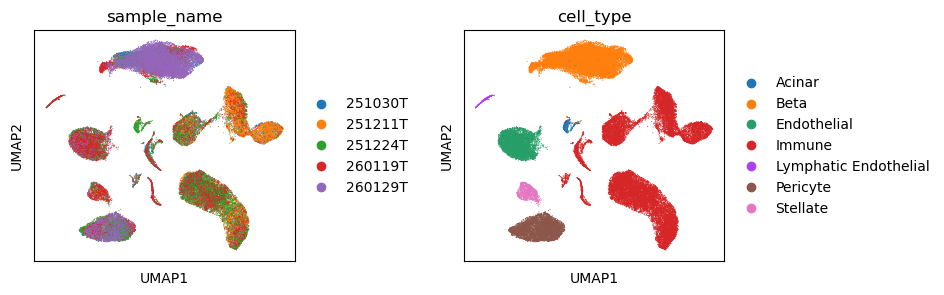

In [52]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata,color=['sample_name','cell_type'],wspace=0.5)

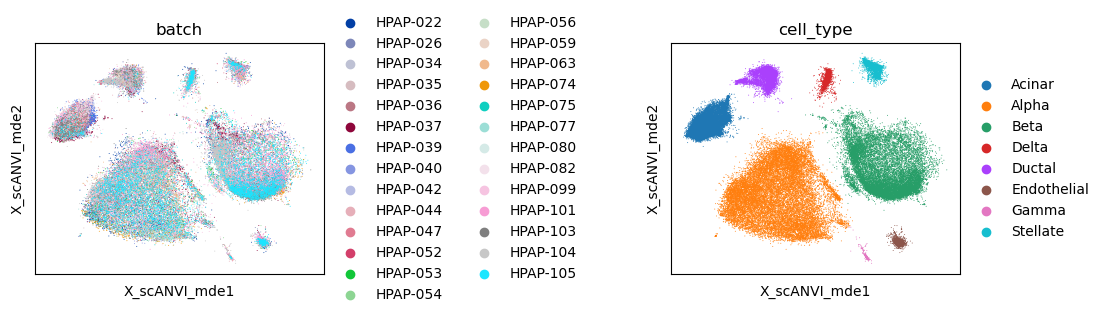

In [53]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.embedding(adata_norm,basis='X_scANVI_mde',color=['batch','cell_type'],wspace=1)

In [54]:
adata_merge = ad.concat([adata_norm,adata],join='outer')

In [55]:
adata_merge.obs

,orig.ident,sample,batch,n_genes,n_counts,percent.mt,cell_type,author,BMI,HbA1c,...,mito_perc,detected_genes,cell_complexity,doublet_score,predicted_doublet,passing_mt,passing_nUMIs,passing_ngenes,leiden,cell_type_level1
HPAP-022_AAGGCAGAGGCATGTG-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,1.984093,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_AAGTCTGAGCTAAACA-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,10.501327,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_AATCCAGGTCAAAGCG-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,11.996497,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_AATCGGTGTACTCTCC-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,11.975831,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_ACACCAACAGCCTGTG-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,0.807382,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260129T#TGGGATTCATAACTGA-1,NaN,NaN,260129T,1139,1999.0,NaN,Immune,NaN,NaN,NaN,...,0.040020,1139.0,0.569785,0.033555,False,True,True,True,43,T
260129T#TGGTTACGTAATGCGA-1,NaN,NaN,260129T,1504,2822.0,NaN,Immune,NaN,NaN,NaN,...,0.031892,1504.0,0.532955,0.013694,False,True,True,True,43,T
260129T#TGTAGTTAGGTTGGTC-1,NaN,NaN,260129T,1256,2143.0,NaN,Immune,NaN,NaN,NaN,...,0.023798,1256.0,0.586094,0.012137,False,True,True,True,41,T
260129T#TGTCGTCCACAGCATG-1,NaN,NaN,260129T,1030,1664.0,NaN,Immune,NaN,NaN,NaN,...,0.029447,1030.0,0.618990,0.035085,False,True,True,True,43,T


In [56]:
adata_merge = run_umap(adata_merge,batch_key='batch')

2026-03-15 16:16:05,466 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-15 16:16:20,963 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-15 16:16:21,494 - harmonypy - INFO - Iteration 1 of 20
2026-03-15 16:17:07,444 - harmonypy - INFO - Iteration 2 of 20
2026-03-15 16:17:52,110 - harmonypy - INFO - Iteration 3 of 20
2026-03-15 16:18:36,549 - harmonypy - INFO - Iteration 4 of 20
2026-03-15 16:19:13,231 - harmonypy - INFO - Converged after 4 iterations


In [57]:
adata_merge.obs

,orig.ident,sample,batch,n_genes,n_counts,percent.mt,cell_type,author,BMI,HbA1c,...,mito_perc,detected_genes,cell_complexity,doublet_score,predicted_doublet,passing_mt,passing_nUMIs,passing_ngenes,leiden,cell_type_level1
HPAP-022_AAGGCAGAGGCATGTG-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,1.984093,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_AAGTCTGAGCTAAACA-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,10.501327,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_AATCCAGGTCAAAGCG-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,11.996497,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_AATCGGTGTACTCTCC-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,11.975831,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
HPAP-022_ACACCAACAGCCTGTG-1,SeuratProject,sample12,HPAP-022,-2147483648,NaN,0.807382,Acinar,Elgamal et al.,NaN,NaN,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260129T#TGGGATTCATAACTGA-1,NaN,NaN,260129T,1139,1999.0,NaN,Immune,NaN,NaN,NaN,...,0.040020,1139.0,0.569785,0.033555,False,True,True,True,43,T
260129T#TGGTTACGTAATGCGA-1,NaN,NaN,260129T,1504,2822.0,NaN,Immune,NaN,NaN,NaN,...,0.031892,1504.0,0.532955,0.013694,False,True,True,True,43,T
260129T#TGTAGTTAGGTTGGTC-1,NaN,NaN,260129T,1256,2143.0,NaN,Immune,NaN,NaN,NaN,...,0.023798,1256.0,0.586094,0.012137,False,True,True,True,41,T
260129T#TGTCGTCCACAGCATG-1,NaN,NaN,260129T,1030,1664.0,NaN,Immune,NaN,NaN,NaN,...,0.029447,1030.0,0.618990,0.035085,False,True,True,True,43,T


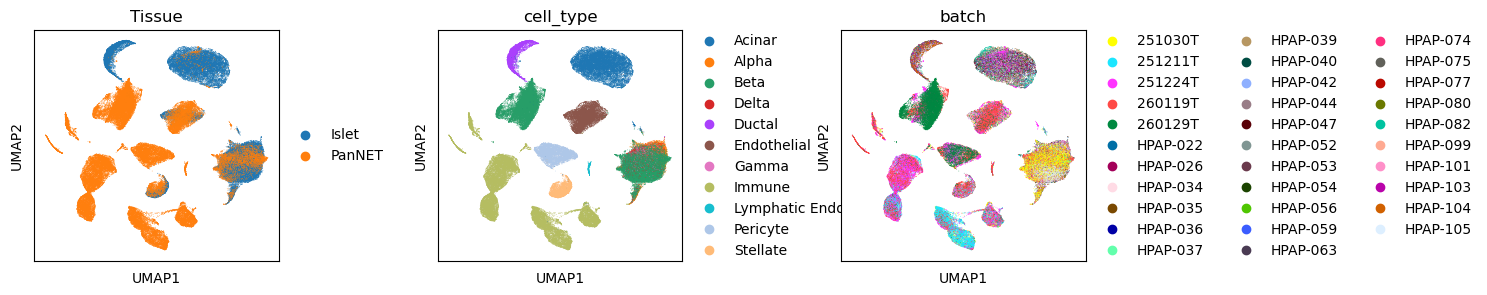

In [ ]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_merge,color=['Tissue','cell_type','batch'],wspace=0.5)

In [72]:
adata_merge.write_h5ad('integrate_h5ad/islet_PanNET_intergtated.h5ad',compression='gzip')

In [98]:
beta_cell = adata_merge[adata_merge.obs['cell_type'] == 'Beta']
beta_cell = beta_cell.raw.to_adata()

In [96]:
beta_cell = run_umap(beta_cell,batch_key='batch',nfeatures=900)

2026-03-15 16:49:04,461 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-15 16:49:08,179 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-15 16:49:08,298 - harmonypy - INFO - Iteration 1 of 20
2026-03-15 16:49:19,374 - harmonypy - INFO - Iteration 2 of 20
2026-03-15 16:49:30,673 - harmonypy - INFO - Iteration 3 of 20
2026-03-15 16:49:41,623 - harmonypy - INFO - Iteration 4 of 20
2026-03-15 16:49:52,581 - harmonypy - INFO - Iteration 5 of 20
2026-03-15 16:50:03,645 - harmonypy - INFO - Iteration 6 of 20
2026-03-15 16:50:14,633 - harmonypy - INFO - Converged after 6 iterations


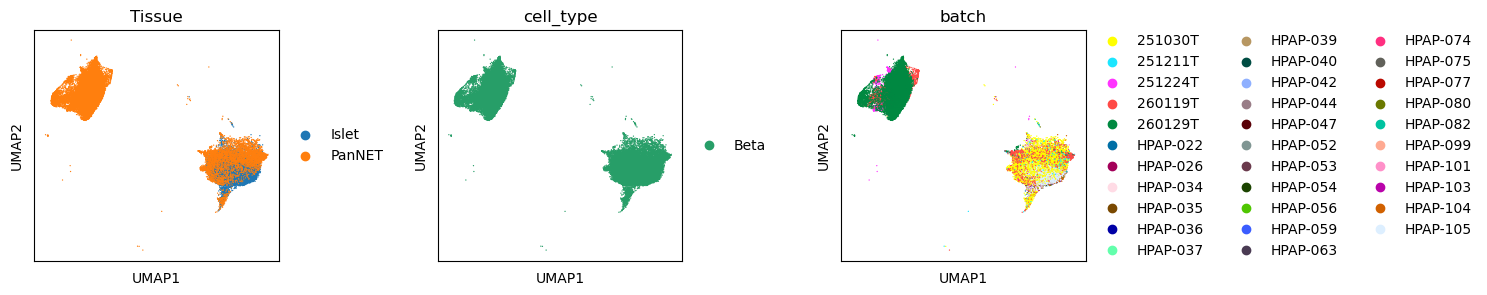

In [99]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(beta_cell,color=['Tissue','cell_type','batch'],wspace=0.5)

In [100]:
beta_cell.write_h5ad('integrate_h5ad/islet_beta_PanNET_intergtated.h5ad',compression='gzip')